✅ Imagen cargada correctamente.
--- PUNTO 1: Filtros de promediado y cruz ---


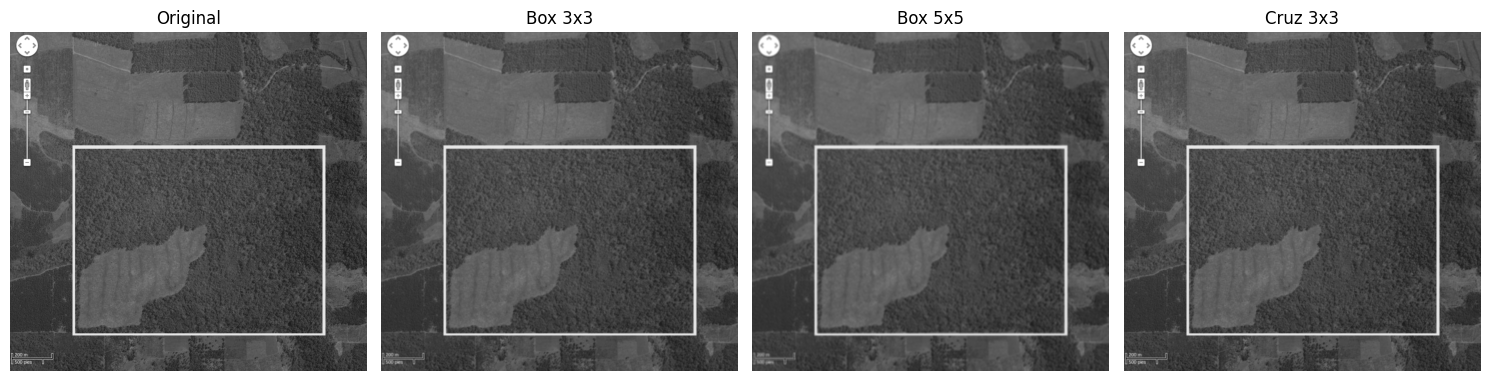

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURACIÓN Y FUNCIONES AUXILIARES
# ==========================================

def mostrar_comparacion(titulos, imagenes, figsize=(15, 4)):
    """Grafica una lista de imágenes lado a lado con sus títulos."""
    n = len(imagenes)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        # Si la imagen es 2D (escala de grises), aplicamos colormap gray
        cmap = 'gray' if len(imagenes[i].shape) == 2 else None
        plt.imshow(imagenes[i], cmap=cmap, vmin=0, vmax=255)
        plt.title(titulos[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# ==========================================
# CARGA DE IMÁGENES
# ==========================================

# Como están en la misma carpeta, solo va el nombre
img = cv2.imread('Deforestacion.png', cv2.IMREAD_GRAYSCALE)
#img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: No se encuentra.")
else:
    print("✅ Imagen cargada correctamente.")
    print("--- PUNTO 1: Filtros de promediado y cruz ---")

    # Generación de máscaras
    kernel_box_3x3 = np.ones((3, 3), np.float32) / 9
    kernel_box_5x5 = np.ones((5, 5), np.float32) / 25
    kernel_cruz_3x3 = np.array([[0, 1, 0],
                                [1, 1, 1],
                                [0, 1, 0]], dtype=np.float32) / 5
    
    # Aplicación de filtros
    img_box_3x3 = cv2.filter2D(img, -1, kernel_box_3x3)
    img_box_5x5 = cv2.filter2D(img, -1, kernel_box_5x5)
    img_cruz_3x3 = cv2.filter2D(img, -1, kernel_cruz_3x3)
    
    mostrar_comparacion(
        ["Original", "Box 3x3", "Box 5x5", "Cruz 3x3"],
        [img, img_box_3x3, img_box_5x5, img_cruz_3x3]
    )

--- EJERCICIO 2: Filtros pasa-altos ---


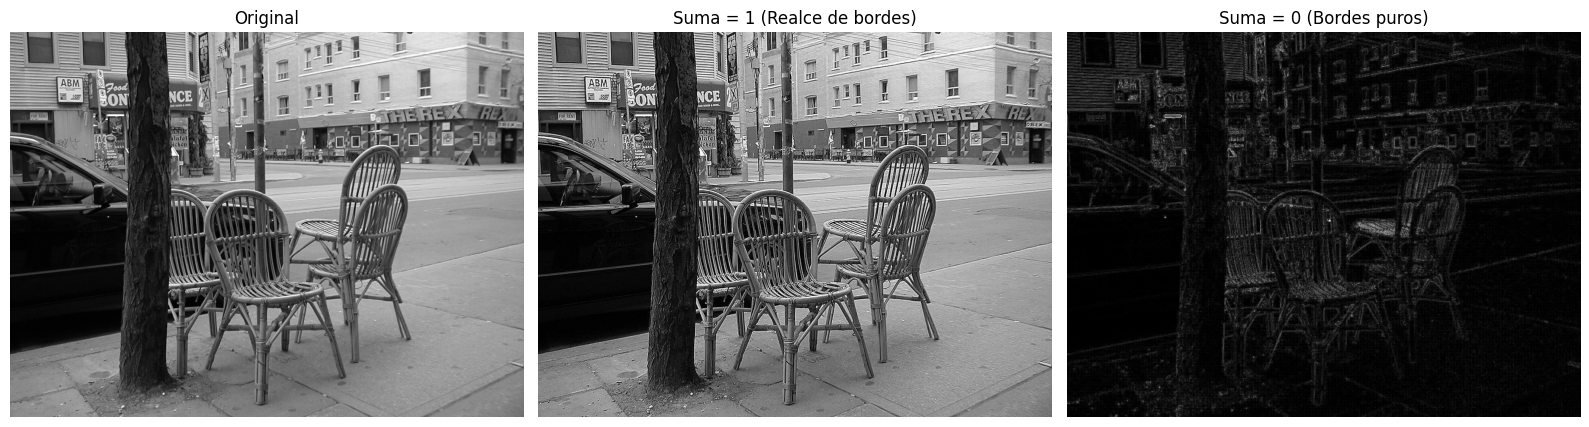

In [ ]:

# Cargamos la imagen 
img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error: No se encuentra.")
else:
    print("--- EJERCICIO 2: Filtros pasa-altos ---")

    # ---------------------------------------------------------
    # PUNTO 2.1: Máscara pasa-altos que suma 1 (Filtro de Realce)
    # ---------------------------------------------------------
    # Si summamos todos los números de esta matriz: 5 - 1 - 1 - 1 - 1 = 1
    kernel_suma_1 = np.array([[ 0, -1,  0],
                              [-1,  5, -1],
                              [ 0, -1,  0]], dtype=np.float32)
    
    # Como suma 1, la imagen resultante se mantiene en rangos normales positivos
    img_suma_1 = cv2.filter2D(img, -1, kernel_suma_1)

    # ---------------------------------------------------------
    # PUNTO 2.2: Máscara pasa-altos que suma 0 (Detección de bordes)
    # ---------------------------------------------------------
    # Si summamos todos los números: 4 - 1 - 1 - 1 - 1 = 0
    # Este es el clásico filtro Laplaciano.
    kernel_suma_0 = np.array([[ 0, -1,  0],
                              [-1,  4, -1],
                              [ 0, -1,  0]], dtype=np.float32)
    
    #Usamos cv2.CV_16S para que no corte los valores negativos al restar.
    img_suma_0_raw = cv2.filter2D(img, cv2.CV_16S, kernel_suma_0)
    
    # Tomamos el valor absoluto para que los bordes negativos también se vean blancos
    img_suma_0 = cv2.convertScaleAbs(img_suma_0_raw)

    # ---------------------------------------------------------
    # VISUALIZACIÓN
    # ---------------------------------------------------------
    mostrar_comparacion(
        ["Original", "Suma = 1 (Realce de bordes)", "Suma = 0 (Bordes puros)"],
        [img, img_suma_1, img_suma_0],
        figsize=(16, 5)
    )

--- EJERCICIO 3: Filtros de Acentuado ---


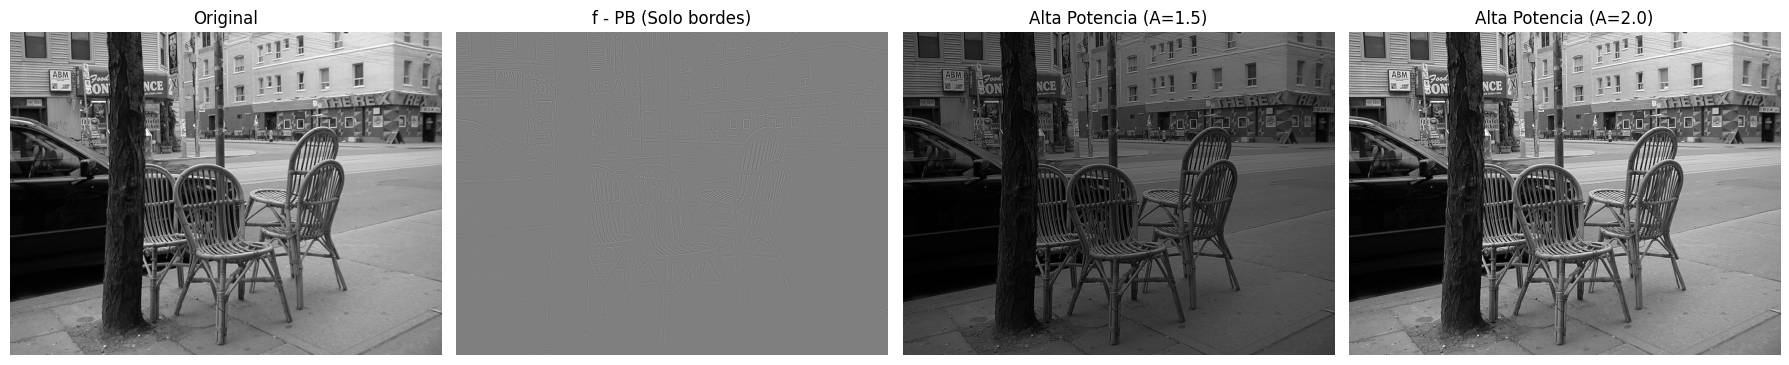

--- Método de Una Pasada (Kernel Combinado para A=2.0) ---


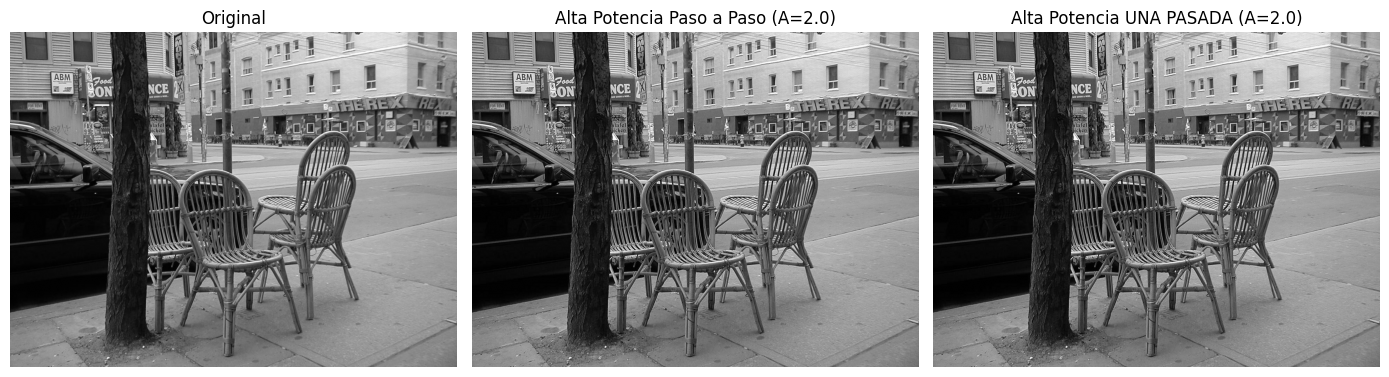

In [4]:

img = cv2.imread('chairs.jpg', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Error")
else:
    print("--- EJERCICIO 3: Filtros de Acentuado ---")

    # 1. CONVERSIÓN A FLOAT PARA NO PERDER DATOS
    f = img.astype(np.float32)

    #Creamos el pasa bajos
    pb=cv2.blur(f,(3,3))

    # ---------------------------------------------------------
    # PUNTO 3.1: Máscara Difusa Básica (A = 1) -> g = f - PB
    # ---------------------------------------------------------
    # Esto aísla los bordes. Le sumamos 128 visualmente para que el fondo 
    # quede gris y los bordes se vean claros/oscuros.
    mascara_bordes = f - pb
    img_bordes = np.clip(mascara_bordes + 128, 0, 255).astype(np.uint8)

    # ---------------------------------------------------------
    # PUNTO 3.2: Alta Potencia (A > 1) -> g = A*f - PB
    # ---------------------------------------------------------
    A1 = 1.5  # intermedio
    A2 = 2.0  # alto

    g_A1 = (A1 * f) - pb
    g_A2 = (A2 * f) - pb

    # Recortamos los valores entre 0-255 y volvemos a formato de imagen
    img_g_A1 = np.clip(g_A1, 0, 255).astype(np.uint8)
    img_g_A2 = np.clip(g_A2, 0, 255).astype(np.uint8)

    mostrar_comparacion(
        ["Original", "f - PB (Solo bordes)", "Alta Potencia (A=1.5)", "Alta Potencia (A=2.0)"],
        [img, img_bordes, img_g_A1, img_g_A2]
    )

    # ---------------------------------------------------------
    # MÉTODO ALTERNATIVO: CÁLCULO EN UNA PASADA
    # ---------------------------------------------------------
    print("--- Método de Una Pasada (Kernel Combinado para A=2.0) ---")
    
    A_una_pasada = 2.0
    
    # 1. Matriz Identidad
    identidad = np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]], dtype=np.float32)
                          
    # 2. Matriz del Box Filter (1/9)
    box_filter = np.ones((3, 3), dtype=np.float32) / 9.0
    
    # 3. Kernel final combinado matemáticamente
    kernel_una_pasada = (A_una_pasada * identidad) - box_filter
    
    # Aplicamos directo a la original con cv2.filter2D
    g_una_pasada_raw = cv2.filter2D(f, -1, kernel_una_pasada)
    img_una_pasada = np.clip(g_una_pasada_raw, 0, 255).astype(np.uint8)

    mostrar_comparacion(
        ["Original", "Alta Potencia Paso a Paso (A=2.0)", "Alta Potencia UNA PASADA (A=2.0)"],
        [img, img_g_A2, img_una_pasada],
        figsize=(14, 5)
    )

